To begin with, the purpose of this notebook is to find more efficient and accurate methods of calculating a gaze vector. I will only compare geometric methods, because ML methods require a GPU.

In [1]:
import io
import cv2
import numpy as np
from PIL import Image
from IPython.display import Image as IPythonImage, display

In [2]:
calibration_path = "camera_calibration.npz"
video_path = "left_eye_video.mp4"

Load hardware configs

In [3]:
led_positions = []

with np.load(calibration_path) as data:
    camera_matrix = np.asarray(data["camera_matrix"], dtype=np.float64)
    camera_distortion = np.asarray(data["dist_coeffs"], dtype=np.float64)

In [4]:
video = cv2.VideoCapture(video_path)

def get_frame(video, frame_index):
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

    ret, frame = video.read()

    if ret:
        # CONSIDER RETURNING GRAYSCALE
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    else:
        print(f"Could not read frame at index {frame_index}")
        return None

def get_image(frame):
    pil_img = Image.fromarray(frame)
    
    img_byte_arr = io.BytesIO()
    pil_img.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()
    
    return IPythonImage(data=img_byte_arr)

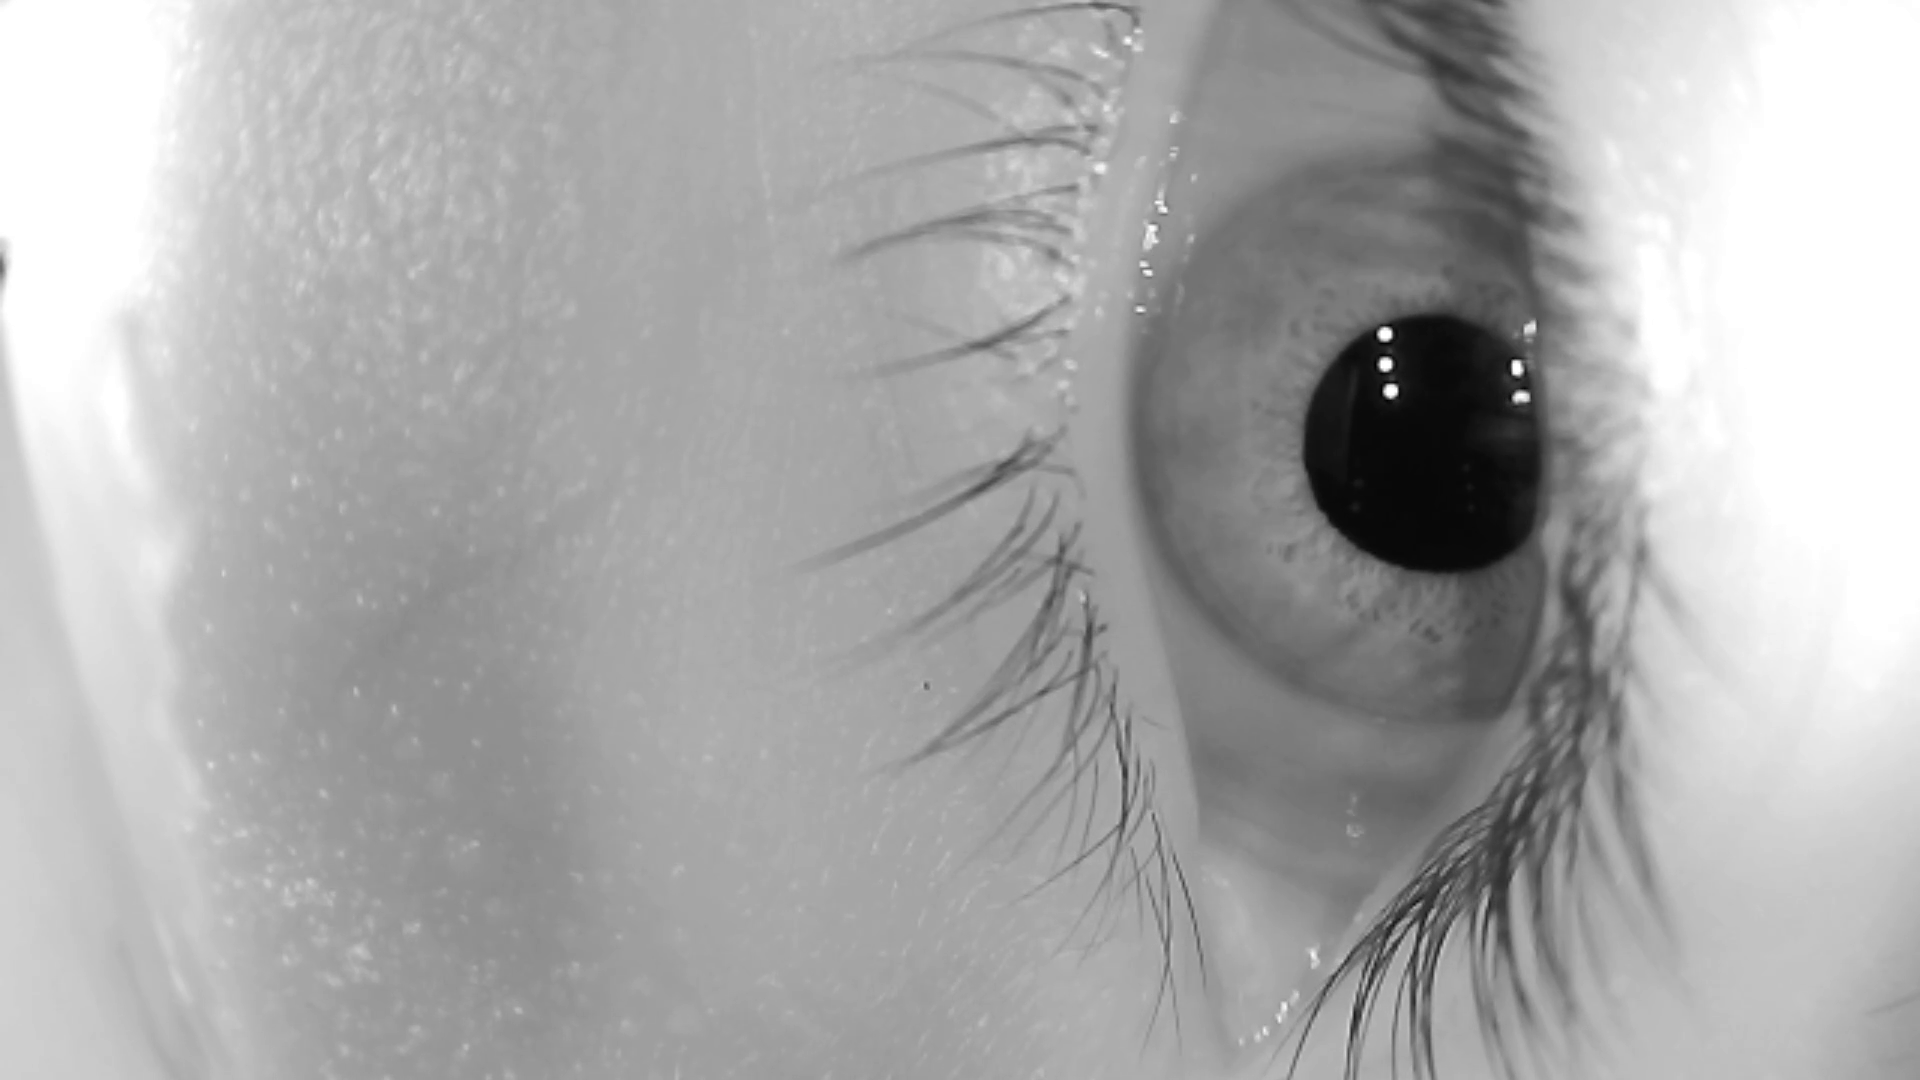

In [5]:
frame = get_frame(video, 5)

clean_image = cv2.undistort(frame, camera_matrix, camera_distortion)

display(get_image(frame))

In [ ]:
def extract_2d_features(frame, config):
    # --- A. Detect Glints (Bright Specular Reflections) ---
    # High threshold to isolate brightest infrared spots
    _, glint_mask = cv2.threshold(frame, thresh=230, maxval=255)
    glint_blobs = cv2.find_connected_components(glint_mask)
    
    glints_2d = {}
    for i, blob in enumerate(glint_blobs):
        # Image moments for sub-pixel accuracy
        u_g = blob.m10 / blob.m00
        v_g = blob.m01 / blob.m00
        glints_2d[f"LED_{i+1}"] = np.array([u_g, v_g, 1.0])

    _, pupil_mask = cv2.threshold(frame, 50, 255, cv2.THRESH_BINARY_INV)
    pupil_contours = cv2.findContours(pupil_mask)
    
    best_pupil_contour = max(pupil_contours, key=cv2.contourArea)
    pupil_ellipse = cv2.fitEllipseDirect(best_pupil_contour)
    (cx, cy), (_, _), _ = pupil_ellipse
    pupil_center_2d = np.array([cx, cy, 1.0])
    
    return glints_2d, pupil_center_2d, pupil_ellipse